In [17]:
#importing all libraries

import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
data = pd.read_csv("iris.csv")

In [19]:
data.isna().sum()
#no null values - can proceed

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [20]:
X = data.drop('species',axis=1)
Y = data['species']
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X,Y,test_size=0.2)

In [21]:
#creating rf
rf = sk.ensemble.RandomForestClassifier(
    n_estimators=30,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=30, random_state=42)

In [6]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search = sk.model_selection.GridSearchCV(
    sk.ensemble.RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}


In [7]:
#Evaluate the model using cross-validation and classification metrics (precision, recall, F1-score).
scores = sk.model_selection.cross_val_score(best_model, X, Y, cv=5, scoring="f1_macro")

print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())
print("Test score:", best_model.score(X_test, y_test))

Cross-validation scores: [0.96658312 0.96658312 0.93265993 0.96658312 1.        ]
Mean CV score: 0.9664818612187034
Test score: 0.9666666666666667


In [8]:
#Perform feature importance analysis to identify the most important features in the dataset.
importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

        Feature  Importance
2  petal_length    0.499455
3   petal_width    0.382748
0  sepal_length    0.107151
1   sepal_width    0.010646


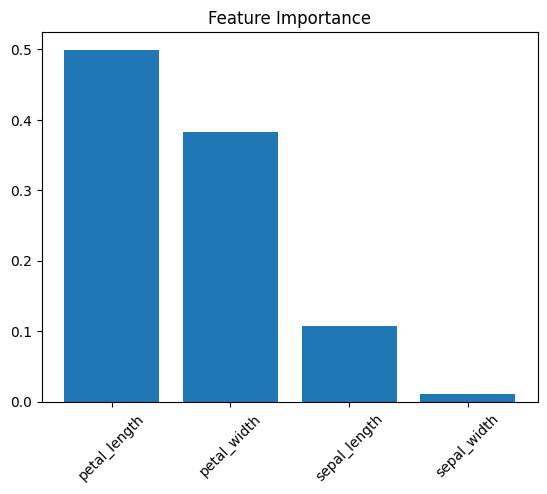

In [9]:
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [10]:
#To create SVM:
#Split data
#Scale features
#Train SVM
#Tune hyperparameters
#Evaluate

In [11]:
#Scale the data
scaler = sk.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
#Evaluate the model using accuracy, precision, recall, and AUC.
svm = sk.svm.SVC(kernel="linear")
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)
print(sk.metrics.classification_report(y_test, pred))
y_test_bin = sk.preprocessing.label_binarize(y_test, classes=['setosa','versicolor','virginica'])
y_score = svm.decision_function(X_test_scaled)
auc = sk.metrics.roc_auc_score(y_test_bin, y_score, multi_class="ovr")
print("AUC:", auc)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

AUC: 1.0


In [13]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]}

grid = sk.model_selection.GridSearchCV(sk.svm.SVC(),param_grid,cv=5,scoring="f1_macro",n_jobs=-1)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [14]:
#comparing different kernels
svm_linear = sk.svm.SVC(kernel="linear")
svm_rbf = sk.svm.SVC(kernel="rbf")

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

pred_linear = svm_linear.predict(X_test_scaled)
pred_rbf = svm_rbf.predict(X_test_scaled)

print("Linear SVM:\n", sk.metrics.classification_report(y_test, pred_linear))
print("RBF SVM:\n", sk.metrics.classification_report(y_test, pred_rbf))

Linear SVM:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

RBF SVM:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



In [15]:
#Using PCA for dimensionality reduction from 4D to 2D

pca = sk.decomposition.PCA(n_components=2)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
le = sk.preprocessing.LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
svm_2 = sk.svm.SVC(kernel="linear")
svm_2.fit(X_train_reduced,y_train_encoded)

SVC(kernel='linear')

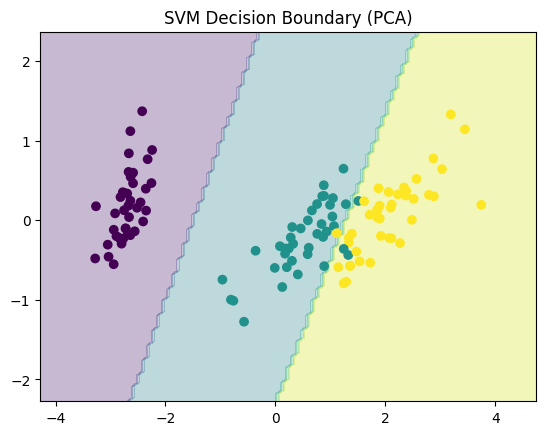

In [16]:
#Visualize the decision boundary.
x_min, x_max = X_train_reduced[:, 0].min() - 1, X_train_reduced[:, 0].max() + 1
y_min, y_max = X_train_reduced[:, 1].min() - 1, X_train_reduced[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = svm_2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], c=y_train_encoded)
plt.title("SVM Decision Boundary (PCA)")
plt.show()